In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

In [390]:
SPLIT_ON_TEST = True

In [391]:
rawPt1 = pd.read_csv('20-09-2026-01-38-06-0x92-0-PT1-W-PROP.csv')
rawPt1 = rawPt1.rename(columns={'data': 'Pt1'})
# [relseconds, Pt1]
# print(rawPt1)

rawPt2 = pd.read_csv('20-09-2026-01-38-06-0x92-1-PT2-W-PROP.csv')
rawPt2 = rawPt2.rename(columns={'data': 'Pt2'})
# [relseconds, Pt2]
# print(rawPt2)

rawFlow = pd.read_csv('20-09-2026-01-38-06-0x96-0-Flowmatic 3000.csv')
rawFlow = rawFlow.rename(columns={'data': 'Flow'})
# [relseconds, Flow]
# print(rawFlow)

rawVelo = pd.read_csv('20-09-2026-01-38-06-0x 5-0-Pump Motor.csv')
rawVelo = rawVelo.rename(columns={'speed': 'Velo'})
# [relseconds, Velo]
# print(rawVelo)

In [392]:
def hampel_filter(df, data_col='data', window=7, n_sigmas=3, output_col='dataWithNoSpikes',
                   timestamp_col='timestamp'):
    """
    Remove short spikes/outliers from a dataset with a DataFrame index and
    a timestamp column.

    Parameters
    ----------
    df : pd.DataFrame
        Input with the (existing) DataFrame index preserved, a timestamp
        column, and a data column.
    data_col : str
        Name of the data column to despike.
    window : int
        Rolling window size (centered).
    n_sigmas : float
        Outlier threshold in robust standard deviations.
    output_col : str
        Name of the output (despiked) column.
    timestamp_col : str
        Name of the timestamp column to carry through.

    Returns
    -------
    pd.DataFrame
        Same index as input, columns: <timestamp_col>, <output_col>
    """
    x = df[data_col].astype(float)
    k = 1.4826  # scales MAD to be comparable to a standard deviation

    rolling_median = x.rolling(window, center=True).median()
    mad = x.rolling(window, center=True).apply(
        lambda w: np.median(np.abs(w - np.median(w))), raw=True
    )
    threshold = n_sigmas * k * mad

    diff = (x - rolling_median).abs()
    outlier_mask = diff > threshold

    cleaned = x.copy()
    cleaned[outlier_mask] = rolling_median[outlier_mask]

    out = pd.DataFrame(index=df.index)
    out[timestamp_col] = df[timestamp_col]
    out[output_col] = cleaned

    return out

In [393]:
despikeVelo = hampel_filter(rawVelo, data_col="Velo", window=100, n_sigmas=1, output_col="F_Velo", timestamp_col='relseconds')
testVelo = rawVelo.merge(despikeVelo, on='relseconds', how="outer")
print(testVelo.iloc[13540])

relseconds     899.249000
Velo          2557.191406
F_Velo        2557.191406
Name: 13540, dtype: float64


<Axes: xlabel='relseconds'>

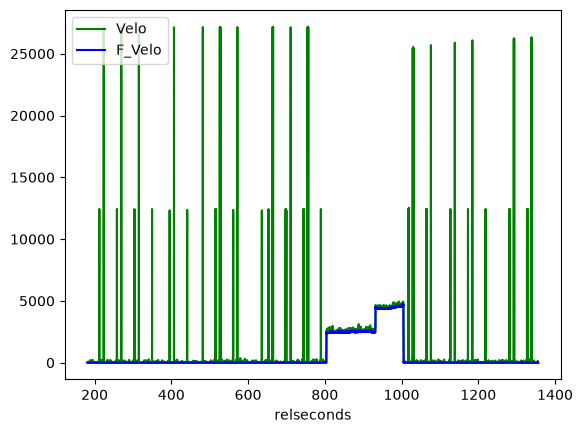

In [394]:
testVelo.plot(x='relseconds', y=['Velo', 'F_Velo'], color=['green', 'blue'])

In [395]:
targetRPM = 2500.0

min = 0
max = 0
minTimestamp = 0.0
maxTimestamp = 0.0

i = 0
for row in despikeVelo.itertuples():
    if min == 0:
        if abs(row.F_Velo - targetRPM) < 500:
            min = i
            minTimestamp = row.relseconds
    else:
        if abs(row.F_Velo - targetRPM) > 500:
            max = i
            maxTimestamp = row.relseconds
            break
        

    
    i += 1

testVelo = testVelo[min:max].reset_index(drop=True)
print(min, max)

11746 14156


<Axes: xlabel='relseconds'>

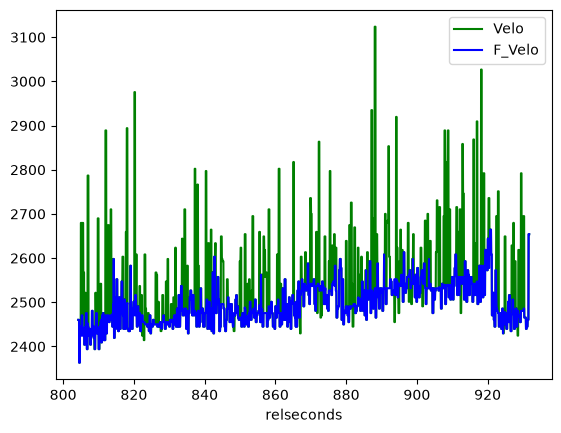

In [396]:
testVelo.plot(x='relseconds', y=['Velo', 'F_Velo'], color=['green', 'blue'])

In [397]:
#combine data
rawCombinedData = rawPt1.merge(rawPt2, on='relseconds', how='outer',)
rawCombinedData = rawCombinedData.merge(rawFlow, on='relseconds', how='outer')
rawCombinedData = rawCombinedData.merge(rawVelo, on='relseconds',how='outer')
rawCombinedData = rawCombinedData.sort_values('relseconds').reset_index(drop=True)

rawCombinedData = rawCombinedData.interpolate('linear')

if SPLIT_ON_TEST:
    i = 0
    for row in rawCombinedData.itertuples(index=True):
        if (row.relseconds > minTimestamp):
            break
        i += 1
    j = 0
    for row in rawCombinedData.itertuples(index=True):
        if (row.relseconds > maxTimestamp):
            j -= 1
            break
        j += 1

    rawCombinedData = rawCombinedData[i:j].reset_index(drop=True)

#get front nan values
i = 0
for row in rawCombinedData.itertuples(index=True):
    # Access columns using the dot notation (row.Column_Name)
    if pd.isna(row.Pt1) or pd.isna(row.Pt2) or pd.isna(row.Flow) or pd.isna(row.Velo):
        pass
    else:
        break

    i += 1

#get back nan values
j = rawCombinedData.shape[0]
for row in rawCombinedData.iloc[::-1].itertuples():
    if pd.isna(row.Pt1) or pd.isna(row.Pt2) or pd.isna(row.Flow) or pd.isna(row.Velo):
        pass
    else:
        break

    j -= 1

#remove nan values from front and back
rawCombinedData = rawCombinedData[i+1:j].reset_index(drop=True)
print(rawCombinedData)

       relseconds        Pt1        Pt2      Flow         Velo
0         804.294  45.664555  53.463203  0.311162  2460.212158
1         804.308  48.639944  54.058281  0.866569  2460.212158
2         804.318  51.615332  54.653358  0.949881  2460.212158
3         804.319  54.590721  55.248436  0.977651  2460.212158
4         804.328  54.590721  54.415327  1.005421  2460.212158
...           ...        ...        ...       ...          ...
14003     931.746  56.375957  63.579525  1.540001  2654.170898
14004     931.751  56.971036  63.579525  1.588599  2734.816845
14005     931.761  57.566114  63.579525  1.644140  2815.462793
14006     931.771  58.161193  63.579525  1.713566  2896.108740
14007     931.785  58.756271  63.579525  1.727451  2976.754688

[14008 rows x 5 columns]


<Axes: xlabel='relseconds'>

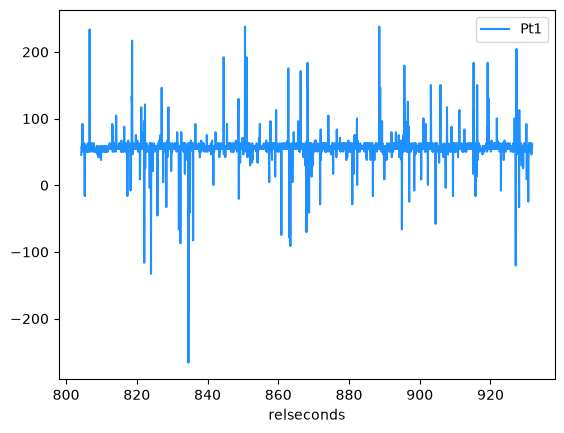

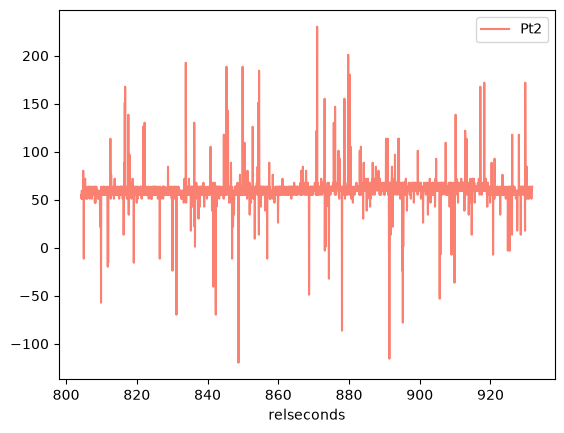

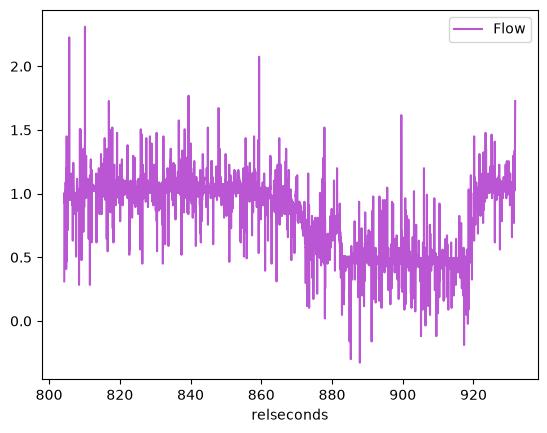

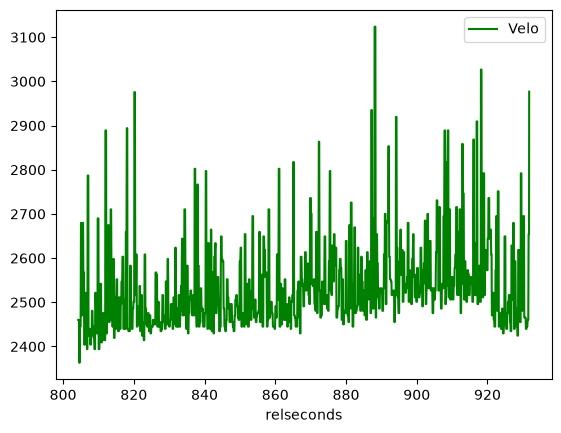

In [398]:
rawCombinedData.plot(x='relseconds',y='Pt1', color='dodgerblue')
rawCombinedData.plot(x='relseconds', y='Pt2', color='salmon')
rawCombinedData.plot(x='relseconds', y='Flow', color='mediumOrchid')
rawCombinedData.plot(x='relseconds', y='Velo', color='green')

In [399]:
def single_pole_iir(df, alpha, columns=None, suffix='_filt', in_place=False, keep_original=True):
    """
    Apply a single-pole IIR (exponential) low-pass filter to a DataFrame.
    Timestamps (and index, if present) pass through unchanged.

    Parameters
    ----------
    alpha : float or dict
        Either a single alpha applied to all `columns`, or a dict like
        {'data1': 0.2, 'data2': 0.05, ...} for per-column smoothing.
    columns : list of str, optional
        Only used if alpha is a single float. Defaults to
        ['data1', 'data2', 'data3', 'data4'].
    suffix : str, optional
        Suffix appended to filtered column names. Ignored if in_place=True.
    in_place : bool, optional
        If True, overwrite the original columns instead of adding new ones.
    keep_original : bool, optional
        If True (default), output includes the raw (unfiltered) data columns
        alongside the filtered ones. If False, only non-data columns
        (e.g. index, timestamp) and the filtered columns are returned —
        the raw data columns are dropped.

    Returns
    -------
    pd.DataFrame
    """
    if isinstance(alpha, dict):
        alpha_map = alpha
    else:
        if not (0 < alpha <= 1):
            raise ValueError("alpha must be in the range (0, 1]")
        cols = columns or ['data1', 'data2', 'data3', 'data4']
        alpha_map = {c: alpha for c in cols}

    missing = [c for c in alpha_map if c not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in dataframe: {missing}")

    filtered_cols = {}
    for col, a in alpha_map.items():
        if not (0 < a <= 1):
            raise ValueError(f"alpha for '{col}' must be in (0, 1], got {a}")
        b = [a]
        den = [1, -(1 - a)]
        x = df[col].to_numpy(dtype=float)
        zi = np.array([(1 - a) * x[0]])
        y, _ = lfilter(b, den, x, zi=zi)
        target_col = col if in_place else f'{col}{suffix}'
        filtered_cols[target_col] = y

    if in_place:
        out = df.copy()
        for col, y in filtered_cols.items():
            out[col] = y
        if not keep_original:
            # in_place + drop-raw is a no-op distinction (same columns either way)
            pass
        return out

    if keep_original:
        out = df.copy()
        for col, y in filtered_cols.items():
            out[col] = y
    else:
        non_data_cols = [c for c in df.columns if c not in alpha_map]
        out = df[non_data_cols].copy()
        for col, y in filtered_cols.items():
            out[col] = y

    return out

In [402]:
alphas = {
    'Pt1': 0.01,
    'Pt2' : 0.01,
    'Flow' : 0.01,
    'Velo' : 0.01
}
filteredData = single_pole_iir(rawCombinedData,alphas)
print(filteredData)

       relseconds        Pt1        Pt2      Flow         Velo   Pt1_filt  \
0         804.294  45.664555  53.463203  0.311162  2460.212158  45.664555   
1         804.308  48.639944  54.058281  0.866569  2460.212158  45.694309   
2         804.318  51.615332  54.653358  0.949881  2460.212158  45.753519   
3         804.319  54.590721  55.248436  0.977651  2460.212158  45.841891   
4         804.328  54.590721  54.415327  1.005421  2460.212158  45.929380   
...           ...        ...        ...       ...          ...        ...   
14003     931.746  56.375957  63.579525  1.540001  2654.170898  54.951363   
14004     931.751  56.971036  63.579525  1.588599  2734.816845  54.971560   
14005     931.761  57.566114  63.579525  1.644140  2815.462793  54.997506   
14006     931.771  58.161193  63.579525  1.713566  2896.108740  55.029143   
14007     931.785  58.756271  63.579525  1.727451  2976.754688  55.066414   

        Pt2_filt  Flow_filt    Velo_filt  
0      53.463203   0.311162  246

<Axes: xlabel='relseconds'>

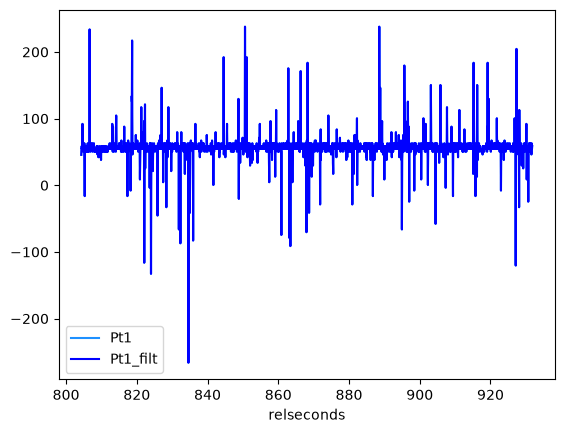

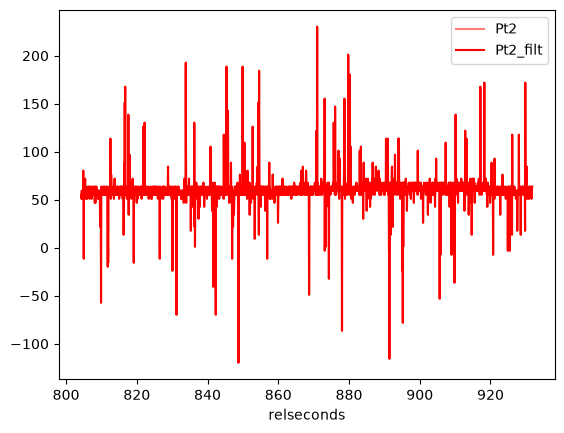

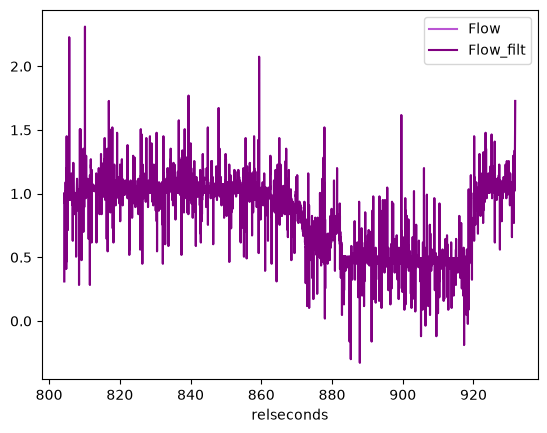

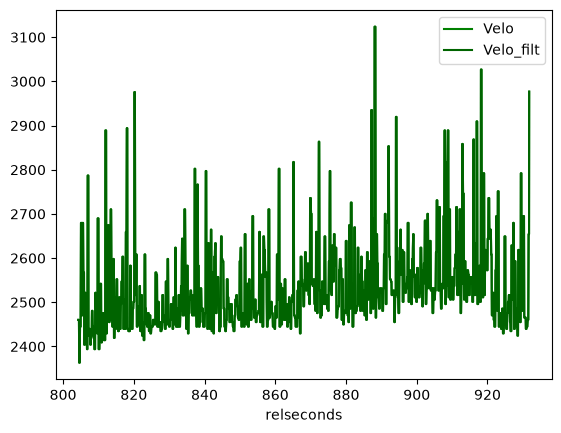

In [401]:
filteredData.plot(x='relseconds',y=['Pt1', 'Pt1_filt'], color=['dodgerblue','blue'])
filteredData.plot(x='relseconds', y=['Pt2', 'Pt2_filt'], color=['salmon', 'red'])
filteredData.plot(x='relseconds', y=['Flow', 'Flow_filt'], color=['mediumOrchid', 'purple'])
filteredData.plot(x='relseconds', y=['Velo', 'Velo_filt'], color=['green', 'darkgreen'])